# 9. Manganese

Manganese is iron's awkward neighbour. It has more accessible oxidation
states, its oxides are stronger oxidants, and — unlike iron — its
intermediate states are genuinely unstable with respect to the ends. Mn(III)
is the textbook disproportionating species, and this notebook watches it
stop disproportionating as the pH rises.

It is also the element where our data has a visible flaw, so it is where we
look at that honestly.

In [1]:
import warnings

import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.figures import frost_diagram, latimer_diagram, plot_frost, plot_latimer, plot_pourbaix
from microbial_thermo.figures.basis import element_grid

warnings.filterwarnings("ignore", category=UserWarning)

## The ladder

In [2]:
ladder = latimer_diagram("Mn", pH=7.0)
ladder.to_frame()

,oxidized,reduced,n electrons,E (V),dG (kJ/mol element),half reaction
0,Pyrolusite,Bixbyite,1.000000,0.562095,-54.233955,Pyrolusite + H+ + e- -> Bixbyite + 1/2 H2O
1,Bixbyite,Hausmannite,0.333333,0.408231,-13.129427,Bixbyite + 1/3 H+ + 1/3 e- -> Hausmannite + 1/...
2,Hausmannite,Mn++,0.666667,0.153133,-9.850032,Hausmannite + 8/3 H+ + 2/3 e- -> Mn++ + 4/3 H2O
3,Mn++,Mn,2.000000,-1.181693,228.032005,Mn++ + 2 e- -> Mn


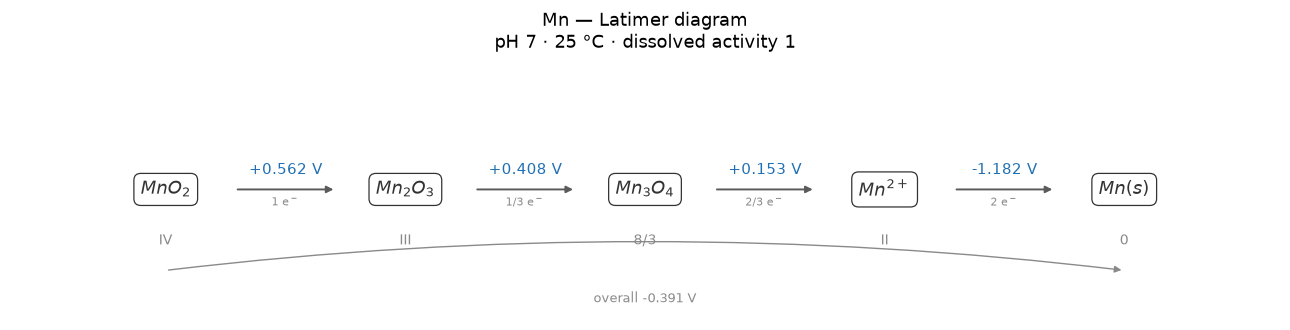

In [3]:
plot_latimer("Mn", diagram=ladder)
plt.show()

Five rungs, two of them mixed-valence oxides. Hausmannite is Mn₃O₄ at
**+8/3** — the manganese analogue of magnetite — and bixbyite is Mn₂O₃ at
+III, with manganite (MnOOH) offered at the same state and beaten to the
rung:

In [4]:
ladder.alternatives

((3.0, 'Manganite'), (3.0, 'Mn+++'))

## Mn(III) disproportionates, until it does not

In [5]:
for ph in (0.0, 2.0, 4.0, 6.0, 7.0, 8.0):
    diagram = frost_diagram("Mn", pH=ph, activity=1e-6)
    off = ", ".join(f"{e.species} {e.delta_g:+.1f}" for e in diagram.disproportionation())
    print(f"pH {ph:4.1f}   {off or 'nothing above the hull'}")

pH  0.0   Hausmannite -60.2, Mn+++ -10.0
pH  2.0   Hausmannite -45.0, Bixbyite -30.0
pH  4.0   Hausmannite -29.8, Bixbyite -18.6
pH  6.0   Hausmannite -14.6, Bixbyite -7.2
pH  7.0   Hausmannite -6.9, Bixbyite -1.5
pH  8.0   Hausmannite -2.1


At pH 2 hausmannite is unstable by 45 kJ per mole and bixbyite by 30. By pH
7 those have fallen to 7 and 1.5 — inside the biological energy quantum,
which is to say effectively at equilibrium.

That is the whole reason Mn(III) is a laboratory curiosity in acid and a
**major environmental species** at circumneutral pH: manganese(III) complexes
are now known to be a large fraction of dissolved manganese in porewaters,
and this is the thermodynamic room they occupy.

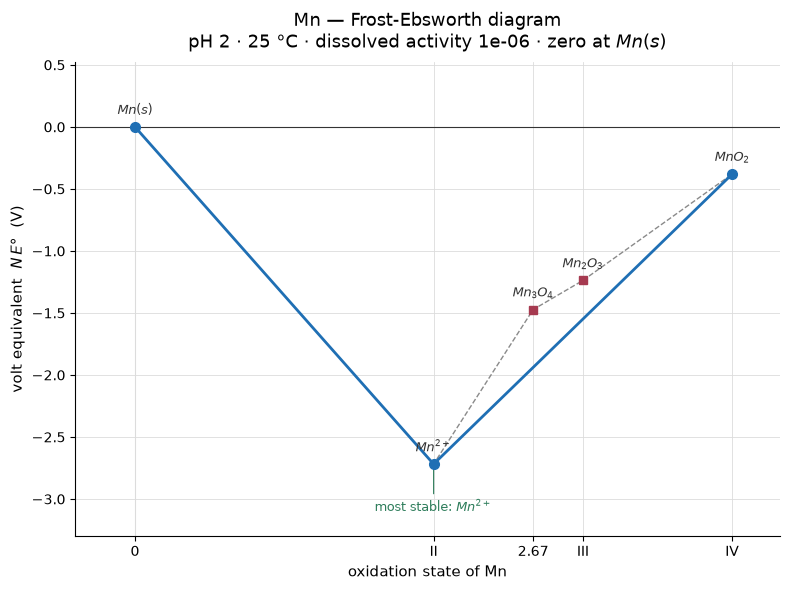

In [6]:
plot_frost("Mn", pH=2.0, activity=1e-6)
plt.show()

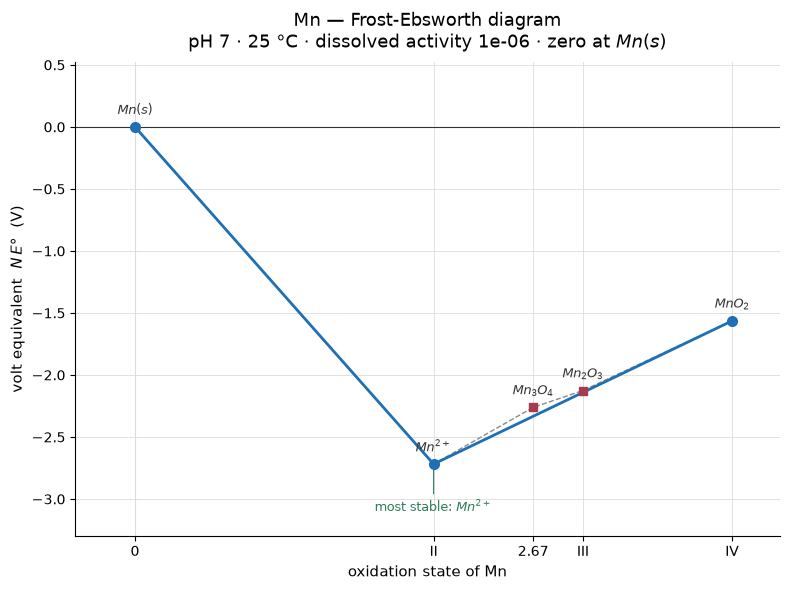

In [7]:
plot_frost("Mn", pH=7.0, activity=1e-6)
plt.show()

## Where each form lives

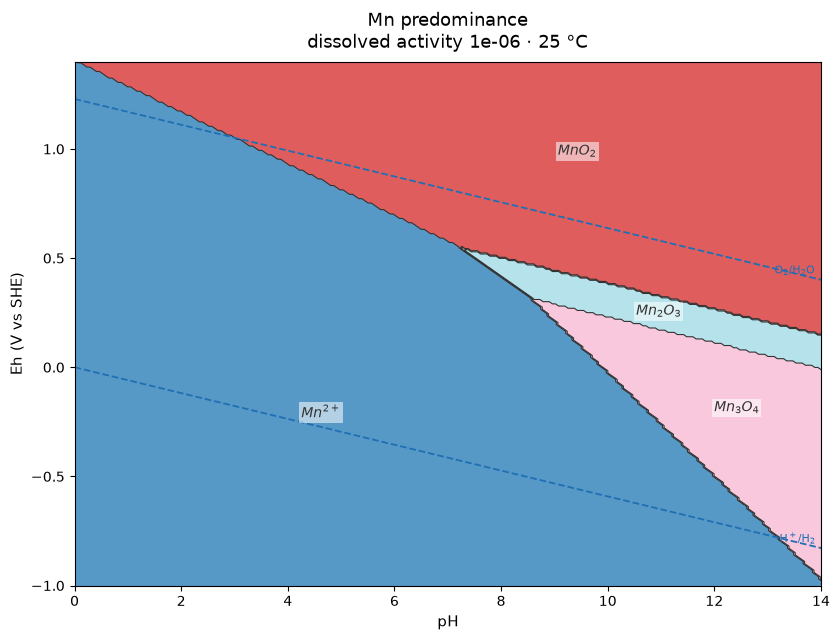

In [8]:
plot_pourbaix("Mn", figsize=(8.5, 6.5))
plt.show()

Mn²⁺ holds nearly the whole field, with the oxides confined to the top right
— high pH *and* strongly oxidising. Compare the iron diagram, where the
ferric oxides take most of the space above the water line. Manganese oxides
are harder to make and easier to reduce, which is why manganese reduction
sits above iron reduction on the redox ladder and why manganese oxides are
the strongest oxidant a sediment normally has after oxygen and nitrate.

## Two things about the data, stated plainly

### Elemental manganese is not zero

In [9]:
backend = mt.get_backend()
for name in ("Mn", "Fe", "Cu", "Zn", "Ni", "As", "Se"):
    print(f"{name:3s} {backend.delta_Gf(name, 25.0).to('kJ/mol').magnitude:+.4f} kJ/mol")

Mn  -2.5064 kJ/mol
Fe  +0.0038 kJ/mol
Cu  +0.0037 kJ/mol


Zn  +0.0040 kJ/mol
Ni  +0.0036 kJ/mol
As  -0.0037 kJ/mol


Se  -0.0028 kJ/mol


Every elemental form should be exactly zero by definition, and every one of
them comes out within 0.004 kJ/mol of it — except manganese, at −2.5. That
is a database problem, not a rounding one, and **any manganese Frost or
Latimer diagram inherits it**: 2.5 kJ/mol over the two-electron Mn²⁺/Mn step
is about 13 mV.

It affects only the metal itself, which no sediment contains, so every
environmentally interesting number above is unaffected. It is recorded here
rather than quietly corrected, because a silently patched database is worse
than a documented flaw.

### Manganite has one temperature

In [10]:
grid = element_grid("Mn", temperatures=(10.0, 25.0, 40.0))
print("on the interactive grid:", grid.species)
for name, why in grid.dropped:
    print(f"\ndropped: {name}\n  {why}")

on the interactive grid: ('Mn', 'Mn++', 'Mn+++', 'Pyrolusite', 'Hausmannite', 'Bixbyite')

dropped: Manganite
  Manganite is tabulated at 25 C only, so its free energy at 10 C is unknown. Evaluate at 25 C, or choose a phase with a full log K grid.


Manganite carries a single log K, at 25 °C, so it can be on the static 25 °C
diagram and cannot be on one with a temperature slider. A phase that appears
and vanishes as a slider moves is a different diagram each time, not the
same diagram at new conditions — so it is dropped from the whole grid and
named on the figure.

Ask for the default manganese ladder away from 25 °C and the library
refuses rather than dropping a phase quietly:

In [11]:
from microbial_thermo.exceptions import OutOfRangeError

try:
    latimer_diagram("Mn", pH=7.0, temperature_c=2.0)
except OutOfRangeError as exc:
    print("refused:", exc)

refused: Manganite is tabulated at 25 C only, so its free energy at 2 C is unknown. Evaluate at 25 C, or choose a phase with a full log K grid.


The fix is to say which species you mean — the grid has already worked out
which ones survive the whole temperature range:

In [12]:
for temperature in (2.0, 25.0, 60.0):
    steps = latimer_diagram(
        "Mn", species=list(grid.species), pH=7.0, temperature_c=temperature
    ).steps
    chain = "  ".join(f"{s.potential:+.3f}" for s in steps)
    print(f"{temperature:5.1f} °C   {chain}")

  2.0 °C   +0.569  +0.451  +0.309  -1.194
 25.0 °C   +0.562  +0.408  +0.153  -1.182


 60.0 °C   +0.548  +0.348  -0.077  -1.162


## Who lives on each step

In [13]:
conditions = mt.Conditions(temperature_c=25.0, pH=7.0)
table = mt.energy_table(conditions).set_index("name")
table.loc[
    [
        "manganese_oxidation_oxygen",
        "manganese_reduction_acetate",
        "manganese_reduction_hydrogen",
    ]
][["label", "dG per e- (kJ/mol)", "reaction"]]

Duplicate found for species "Fluorphlogopite" in supcrtbl.dat
Duplicate found for species "Arsenic" in supcrtbl.dat
Duplicate found for species "Arsenolite" in supcrtbl.dat


,label,dG per e- (kJ/mol),reaction
name,,,
manganese_oxidation_oxygen,Manganese(II) oxidation with oxygen,-44.162314,Mn++ + H2O + 1/2 O2(aq) -> Pyrolusite + 2 H+
manganese_reduction_acetate,Manganese(IV) reduction with acetate,-64.601953,1/4 Acetate + 9/4 H+ + Pyrolusite -> 1/2 CO2(a...
manganese_reduction_hydrogen,Manganese(IV) reduction with hydrogen,-78.562774,2 H+ + H2(g) + Pyrolusite -> Mn++ + 2 H2O


Put manganese reduction beside iron reduction on the same donor and the
redox zonation stops being a list to memorise:

In [14]:
for name in ("manganese_reduction_hydrogen", "goethite_reduction_hydrogen"):
    print(f"{table.loc[name, 'label']:44s} {table.loc[name, 'dG per e- (kJ/mol)']:+7.1f} kJ/mol e-")

Manganese(IV) reduction with hydrogen          -78.6 kJ/mol e-
Goethite reduction with hydrogen                +2.6 kJ/mol e-


Hydrogen against manganese oxide pays about −79 kJ/mol e⁻; hydrogen against
goethite does not pay at all at standard state. That gap is why manganese is
consumed above iron in a sediment profile, and it is larger than most
textbook ladders suggest — because those ladders draw MnO₂ and FeOOH as
though they were comparable phases, and thermodynamically they are not
close.

## One thing worth taking away

Manganese oxidation by oxygen is exergonic but notoriously slow abiotically,
and manganese-oxidising bacteria are catalysing a reaction that
thermodynamics has already approved. Manganese reduction is the reverse and
pays well. Between them sits Mn(III), too unstable to accumulate in acid and
stable enough to matter at pH 7 — which is why the manganese cycle has a
genuine three-species character that the iron cycle does not.